<div align="center">
    <h2> Project Title <br> 
    <h4> Samantha Becvar & Eric Lee <br> University of Washington, Department of Mechanical Engineering Master's Program <br> M E 569 C <br> Dr. Steven Brunton
</div>

In [31]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [35]:
# environment(bounds)
# Args
#   bounds - the boundary of our environment, x_bounds and y_bounds
# Returns
#   None

def environment(bounds):
    x_min, x_max, y_min, y_max = bounds
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("Environment")

In [33]:
# create_pedestrians(num_pedestrians, bounds, radius)
# Args
#   num_peds - number of pedestrians in our environment
#   bounds - bounds of our environment
#   radius - the radius of our pedestrians, to ensure our pedestrians stay in the bounds of our environment
# Returns
#   peds - an array of pedestrian (x, y) locations
def create_pedestrians(num_peds, bounds, radius):
    x_bounds = np.array([bounds[0]+radius, bounds[1]-radius])
    y_bounds = np.array([bounds[2]+radius, bounds[3]-radius])

    peds = []

    for _ in range(num_peds):
        x = random.uniform(x_bounds[0], x_bounds[1])
        y = random.uniform(y_bounds[0], y_bounds[1])

        peds.append((x,y))

    return peds

# plot_pedestrians(ax, peds, radius)
# Args
#   ax - the axis, for ploting purposes
#   peds - the pedestrian locaitons from create_pedestrians
#   radius - the radius of our pedestrians
# Returns
#   None
def plot_pedestrians(ax, peds, radius):

    for x, y in peds:
        pedestrian = Circle(
            (x, y),
            radius,
            facecolor='orange',
            edgecolor='black',
            linewidth=2,
            alpha=0.7
        )

        ax.add_patch(pedestrian)

In [37]:
def plot_robot(ax, x, y, width, height, heading):

    # create the robot body
    robot = Rectangle(
        (x - width/2, y - height/2),
        width,
        height,
        facecolor='red',
        edgecolor='black',
        linewidth=2
    )

    ax.add_patch(robot)

    # create direction arrow
    arrow_length = 2

    dx = arrow_length * np.cos(heading)
    dy = arrow_length * np.sin(heading)

    ax.arrow(
        x,
        y,
        dx,
        dy,
        head_width=0.5,
        head_length=0.7,
        fc='black',
        ec='black'
    )

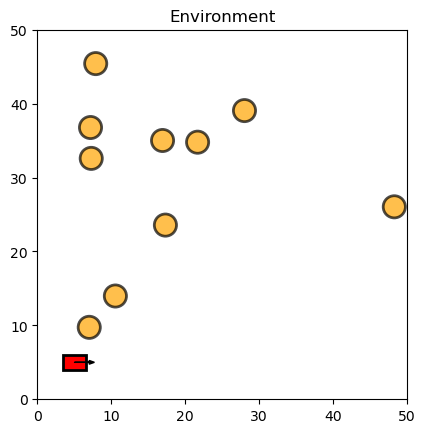

In [43]:
# set-up details
env_dims = np.array([0, 50, 0, 50])
robot_loc = np.array([5, 5])
robot_size = np.array([3, 2])
heading = np.pi * 2
num_people = 10
radius = 1.5

fig, ax = plt.subplots()

# call functions
environment(env_dims)
pedestrians = create_pedestrians(num_people, env_dims, radius)

# create plots
plot_pedestrians(ax, pedestrians, radius)
plot_robot(ax, robot_loc[0], robot_loc[1], robot_size[0], robot_size[1], heading)
plt.gca().set_aspect('equal')
plt.show()